# Scenario B2 Forecasts: Multiple Suppliers with REC — Explicit Forecast Scheduling (Net Generators)

**Description:** Multi-supplier REC scenario identical to B2 but where DA and ID market scheduling
uses dedicated per-participant forecast CSV files rather than falling back to actuals. Prosumers are
**net generators** (RES only, no local load). Imbalances reflect the error between the ID forecast
position and the REC-corrected actual position.

**Participant–supplier assignment:**
| Supplier / BG | Participants |
|---|---|
| SUP_A / BG_A | prosumer_001 (Fire Station) · consumer_001–004 |
| SUP_B / BG_B | prosumer_002 · prosumer_003 · consumer_005 (Bank) · consumer_006 |

**Configuration:**
| Parameter | Value |
|---|---|
| Suppliers | 2 — SUP_A, SUP_B |
| Balancing Groups | 2 — BG_A, BG_B (heterogeneous — each contains prosumers + consumers) |
| RECs | 1 — REC_01 (all 9 members, proportional sharing) |
| Prosumer type | **Net generator** (RES only, no local load) |
| Forecast mode | Explicit DA + ID forecast CSVs per participant |
| REC incentives | Shared energy: 0.01 €/kWh · Self-consumption: 0.015 €/kWh |
| Battery | None |

**Comparison pairs (net-generator track):**
- B2-forecasts vs B2 → impact of forecast error on imbalance costs (perfect info vs forecasts)
- B2-forecasts vs A2 → multi-supplier + forecasts vs single-supplier with actuals
- B2-forecasts vs B1 → REC value under explicit forecast scheduling

## 1. Import Dependencies
Import the EnergyMarketOperations class which handles the complete market simulation pipeline.

In [1]:
from energy_market_operations import EnergyMarketOperations

## 2. Initialize Pipeline
Load the scenario configuration from JSON and create the pipeline instance. The config specifies participants, suppliers, market prices, and network topology.

In [2]:
CONFIG_FILE = "B2_multiple_supplier_with_rec_forecasts.json"
pipe = EnergyMarketOperations(CONFIG_FILE, scenario_name="B2_forecasts")

## 3. Run Full Pipeline
Execute the complete market simulation:
1. **Day-Ahead Market** - Schedule energy positions based on DA forecasts (per BG)
2. **Intra-Day Market** - Adjust positions with updated ID forecasts (per BG)
3. **REC Settlement** - Proportional energy sharing within community
4. **Balancing Market** - Settle imbalances at dual pricing (per BG)
5. **Supplier Billing** - Calculate final costs per participant

In [3]:
pipe.run_all()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Running full pipeline for: B2_forecasts
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  SCENARIO: B2_forecasts
  System  : Multiple Suppliers with REC - REC-Aware Forecast - Scenario B2-Forecasts
  Period  : 2016-01-01 → 2016-12-31
  Suppliers    : 2
  Prosumers    : 3
  Consumers    : 6
  RECs         : 1  →  has_rec = True
  Battery      : False
✓ Prices loaded: (35136, 5)  from prices.csv
✓ Load actual : (35136, 153)
✓ RES actual  : (35136, 27)
✓ Load forecast DA: (35136, 6)
✓ RES  forecast DA: (35136, 3)
✓ Load forecast ID: (35136, 6)
✓ RES  forecast ID: (35136, 3)
✓ DA market: (70272, 8)
✓ ID market : (70272, 19)
⚠ Battery optimization: skipped (no battery in config)
✓ REC settlement: 1 REC(s) processed
✓ Balancing market: (70272, 31)
✓ Customer billing: (316224, 12)  (9 customers)
✓ Monthly aggregation: (24, 27)
✓ Profit/loss calculated

━━━━━━━━━━━━━━━━━━━━━━━━

## 4. Financial Summary
Display aggregated financial results including total revenues, costs, and profit/loss for each supplier.

In [4]:
pipe.summary()


  ANNUAL FINANCIAL SUMMARY – B2_FORECASTS

  SUP_A (Supplier A):

    REVENUES:
      Energy Market Sales : €       74.50
      Balancing Rewards   : €      102.61
      Retail Sales        : €    8,995.44
      ────────────────────────────────────────────
      Total Revenue       : €    9,172.54

    COSTS:
      Market Purchases    : €    1,839.71
      Balancing Penalties  : €      364.47
      Retail Purchases     : €      357.08
      ────────────────────────────────────────────
      Total Costs          : €    2,561.26

    PROFIT/LOSS:
      Annual Total         : €    6,611.28
      Monthly Average      : €      550.94

    IMBALANCE:
      System Position      : LONG
      Total Imbalance      :        -9.47 MWh
      BG Actual Position   :        40.42 MWh
      BG Forecast Position :        49.89 MWh

    REC SHARING:
      Shared Energy        :        35.73 MWh

  SUP_B (Supplier B):

    REVENUES:
      Energy Market Sales : €      343.35
      Balancing Rewards   : € 

## 5. Financial Visualization
Plot breakdown of revenues and costs by category (DA purchases, ID adjustments, balancing costs, customer sales).

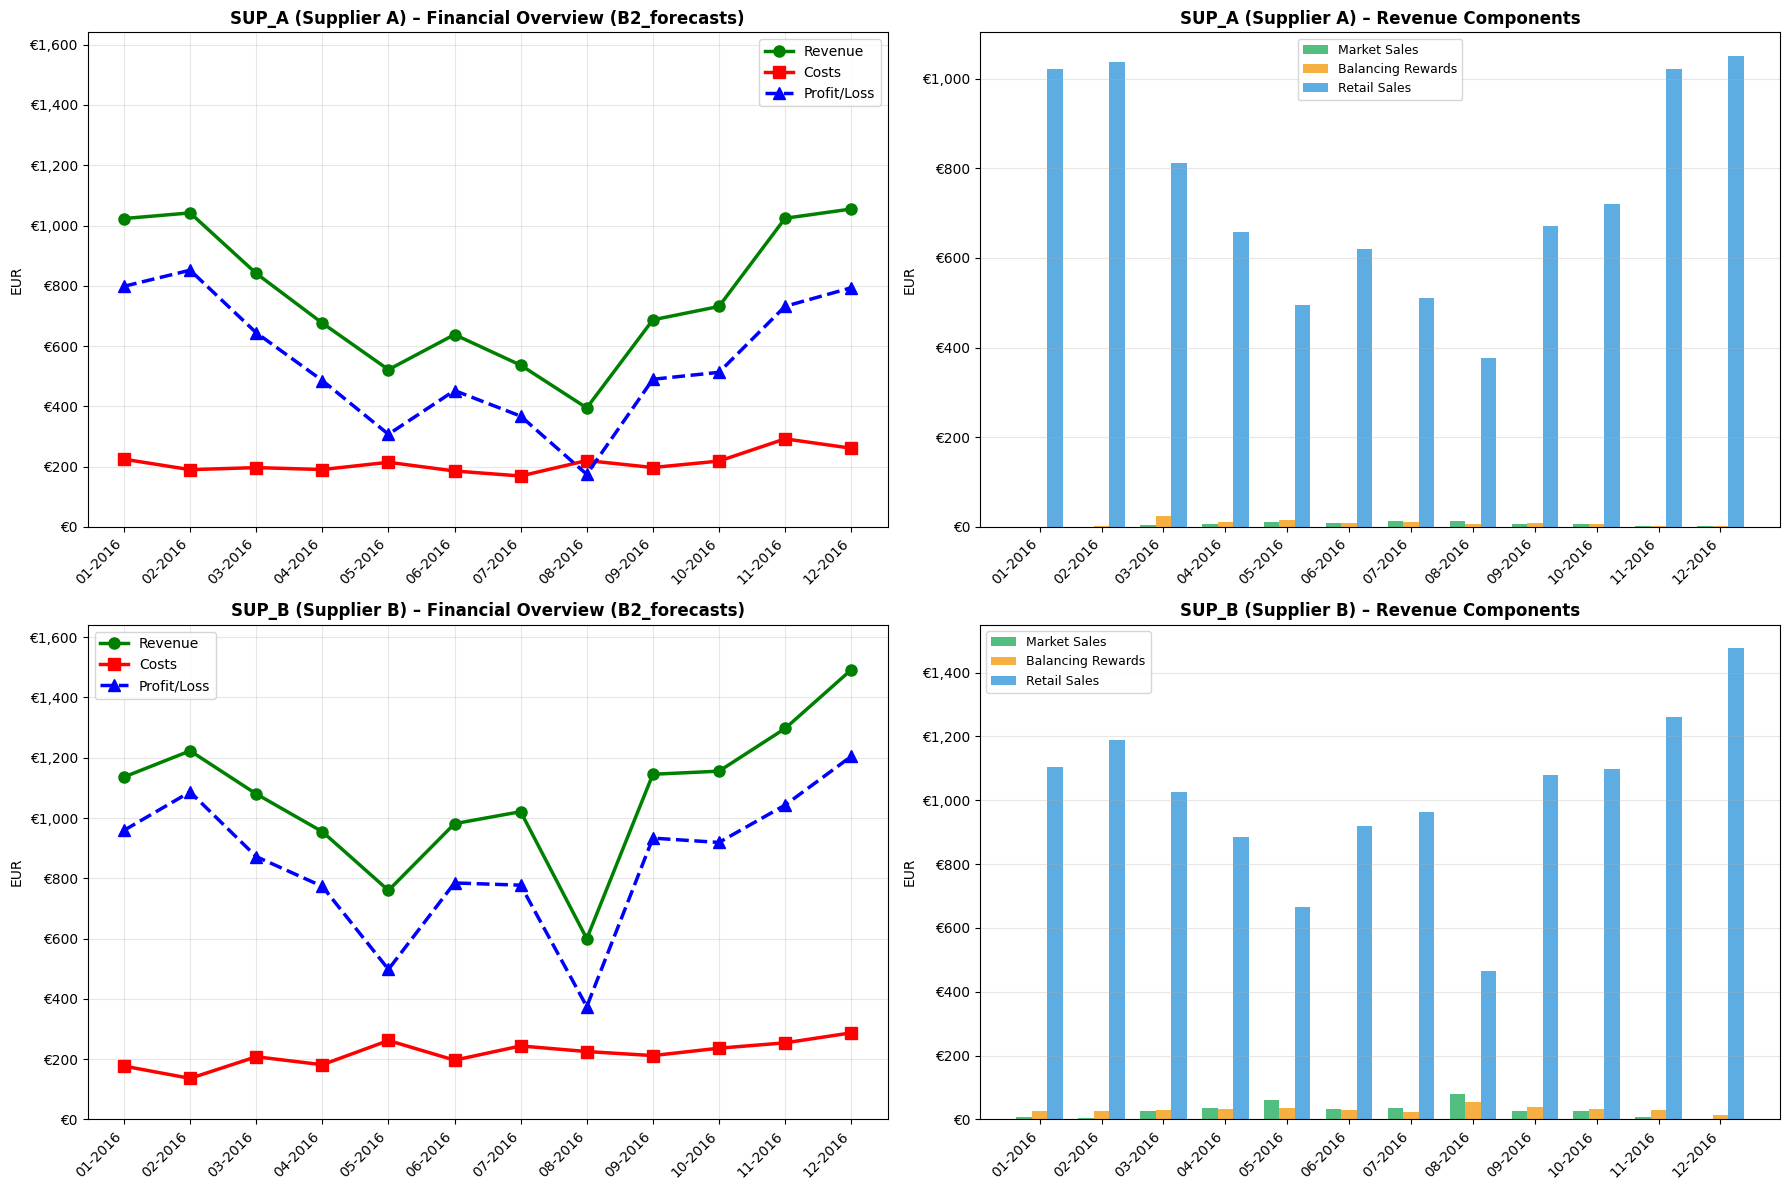

In [5]:
pipe.plot_financials()

## 6. Imbalance Analysis
Visualize system imbalances over time showing the difference between scheduled positions and actual metered values.

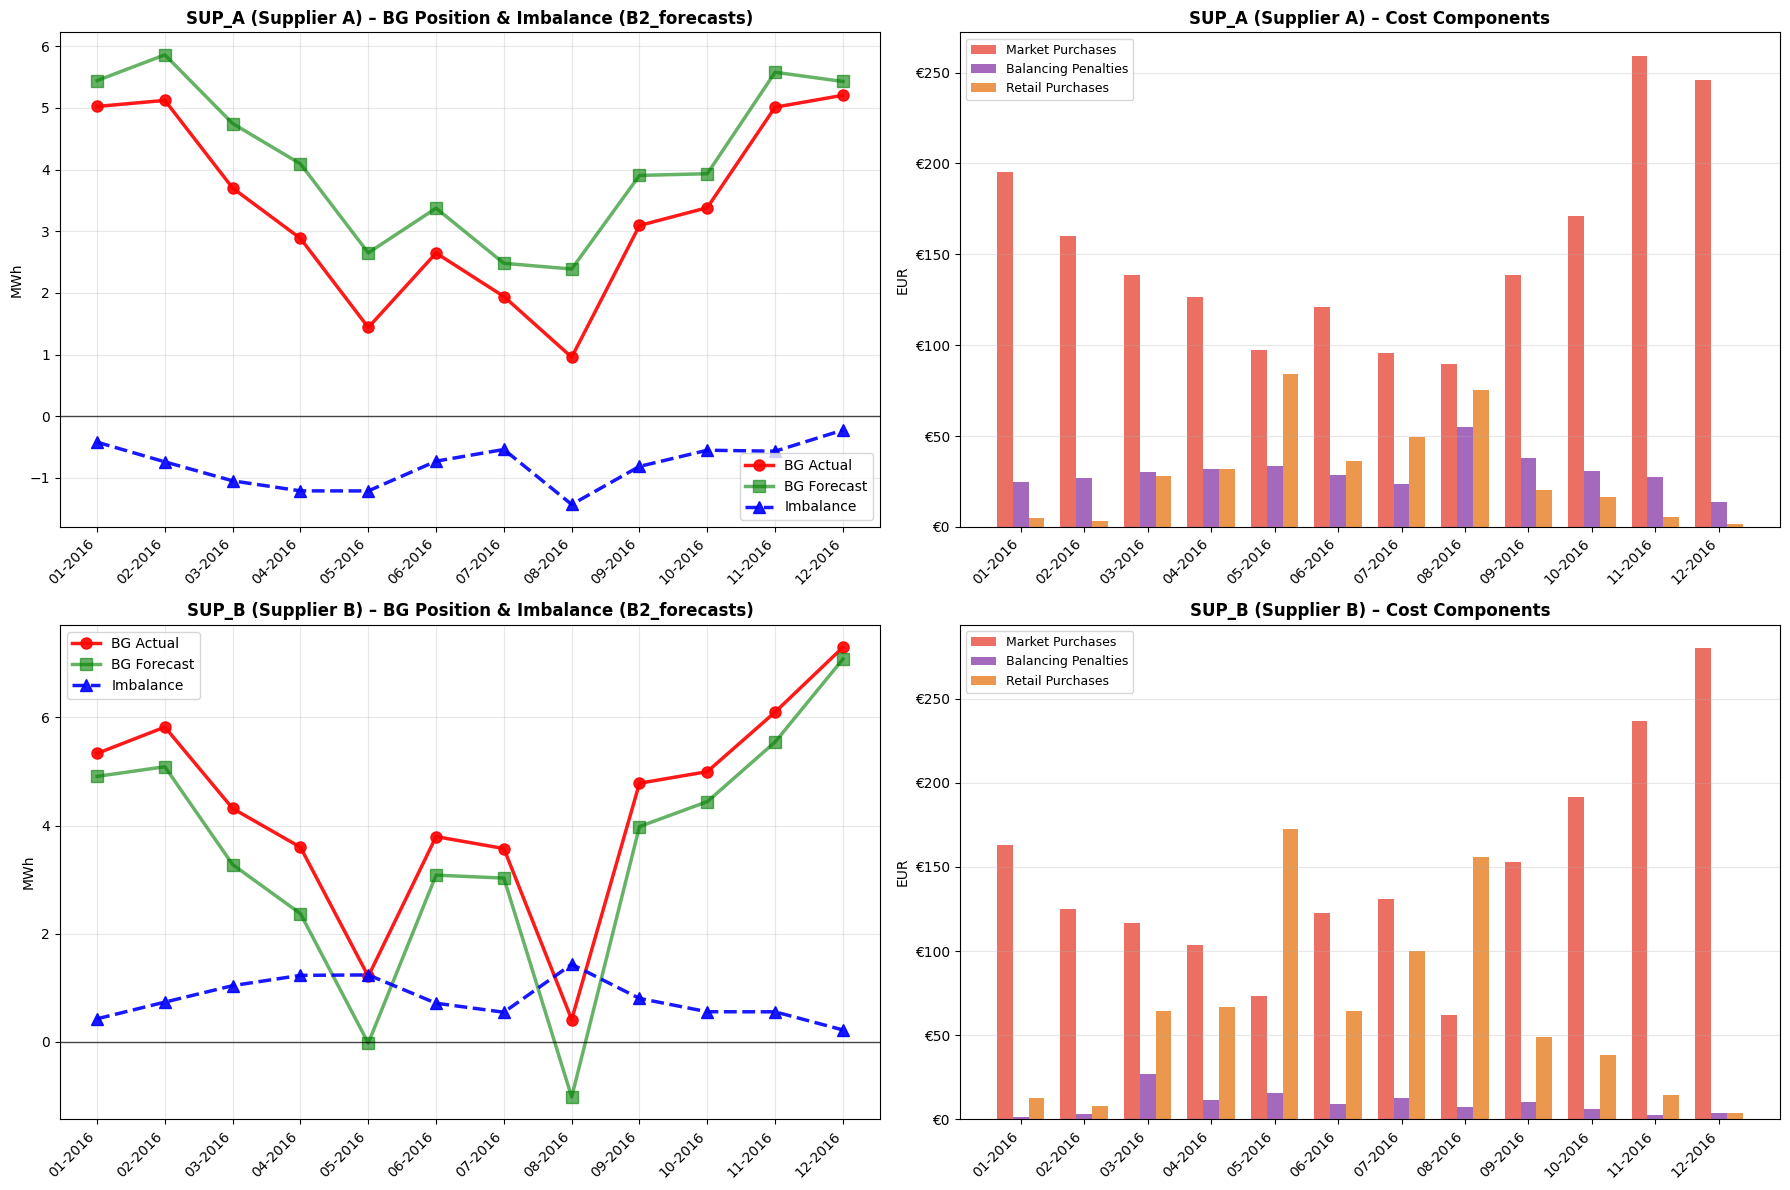

In [6]:
pipe.plot_imbalances()

## 7. Monthly Analysis
Monthly aggregated results including energy volumes, market costs, and REC sharing.

In [7]:
pipe.es_monthly_analysis_df

,datetime,supplier_id,balancing_group_id,da_net_load_forecast_mwh,da_net_gen_forecast_mwh,da_purchase_commitment_eur,da_sale_commitment_eur,id_net_load_adjustment_mwh,id_net_gen_adjustment_mwh,id_price_eur_per_mwh,...,internal_shared_energy_mwh,revenue_energy_market_sales_eur,revenue_balancing_rewards_eur,revenue_retail_sales_eur,total_revenue_eur,cost_energy_market_purchases_eur,cost_balancing_penalties_eur,cost_retail_purchases_eur,total_costs_eur,profit_loss_eur
0,01-2016,SUP_A,BG_A,6.056488,0.025867,216.148583,0.586912,-0.580173,0.006026,29.579375,...,1.107789,0.745549,0.898679,1021.647937,1023.292165,195.471141,24.554320,4.779446,224.804906,798.487259
1,01-2016,SUP_B,BG_B,5.768645,0.239767,181.807232,6.652541,-0.584524,0.035254,29.579375,...,1.722950,7.719744,25.570024,1102.962650,1136.252418,162.997437,1.369641,12.666372,177.033450,959.218968
2,02-2016,SUP_A,BG_A,6.551711,0.043110,177.166506,0.674960,-0.640662,0.005519,22.463459,...,2.137292,0.766182,3.121888,1038.029782,1041.917853,159.922961,26.742800,3.363541,190.029301,851.888551
3,02-2016,SUP_B,BG_B,6.018472,0.210609,140.462110,4.355918,-0.651947,0.068191,22.463459,...,3.029320,5.963243,27.153473,1189.879898,1222.996614,124.804201,3.431258,8.116445,136.351904,1086.644710
4,03-2016,SUP_A,BG_A,5.646675,0.277568,155.091506,3.928116,-0.603281,0.017964,24.094009,...,3.478539,4.288929,25.057074,811.834583,841.180586,138.619687,30.446326,27.856301,196.922314,644.258272
5,03-2016,SUP_B,BG_B,5.138007,1.181246,130.844675,22.450934,-0.550704,0.128904,24.094009,...,4.575315,25.620737,30.269327,1024.147336,1080.037400,116.617663,27.133790,64.269072,208.020525,872.016875
6,04-2016,SUP_A,BG_A,5.055087,0.336253,143.055218,6.641771,-0.591548,0.033446,25.257687,...,4.523016,7.232423,11.130103,657.964757,676.327283,126.505189,31.948409,32.067903,190.521502,485.805781
7,04-2016,SUP_B,BG_B,4.422755,1.376791,116.584484,31.282450,-0.490601,0.186039,25.257687,...,5.901503,35.966724,32.971515,885.825166,954.763406,103.462349,11.372786,66.688723,181.523858,773.239548
8,05-2016,SUP_A,BG_A,3.902607,0.720406,110.271526,10.557107,-0.464673,0.066935,22.993579,...,4.275324,11.763903,15.955938,494.218617,521.938458,97.208617,33.399439,83.922820,214.530876,307.407581
9,05-2016,SUP_B,BG_B,3.368035,2.815254,83.106895,54.561632,-0.376955,0.201375,22.993579,...,5.776670,59.448316,35.916592,664.527477,759.892384,73.494647,15.833024,172.646609,261.974280,497.918104
